<img src="http://drive.google.com/uc?export=view&id=1tpOCamr9aWz817atPnyXus8w5gJ3mIts" width=500px>

## Lab on NNDL Part 1: Tensorflow Basic

### Tensors

Tensors are multi-dimensional arrays with a uniform type

In [2]:
#prepare axccess to GDrive
#Mount your Google drive so you can read them easilu
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import os
os.chdir('/content/gdrive/MyDrive/Colab Notebooks/NNDL')
os.getcwd()

'/content/gdrive/MyDrive/Colab Notebooks/NNDL'

##Question 1


### Create a rank-0 tensor
- A "scalar" is called "rank-0" tensor
- the tensor should contain value 99.99

In [76]:
%tensorflow_version 2.x
import tensorflow as tf
import numpy as np

In [77]:
# This will be an int32 tensor by default; see "dtypes" below.
rank_0_tensor = tf.constant(99.99)
print(rank_0_tensor)

tf.Tensor(99.99, shape=(), dtype=float32)


### Create a rank-1 tensor

- A "vector" (list) is called "rank-1" tensor [9,8,7,6,5]
- A vector has one axis

In [78]:
rank_1_tensor = tf.constant([9, 8, 7, 6, 5])
print(rank_1_tensor)

tf.Tensor([9 8 7 6 5], shape=(5,), dtype=int32)


### Add 7 to all the elements of the above created tensor
- Use Broadcasting

In [79]:
print(tf.add(rank_1_tensor, 7))

tf.Tensor([16 15 14 13 12], shape=(5,), dtype=int32)


In [80]:
print(rank_1_tensor+7)

tf.Tensor([16 15 14 13 12], shape=(5,), dtype=int32)


### Create a rank-2 tensor
[[1, 2, 3], [ 4,5,6]]
- A "matrix"  "is called rank-2" tensor
- It has 2 axes

In [81]:
rank_2_tensor = tf.constant([[1, 2, 3], [4, 5, 6]])
print(rank_2_tensor)

tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)


### Change the shape of the above created tensor to shape (3,2)

In [82]:
reshaped = tf.reshape(rank_2_tensor, [3, 2])
print(reshaped)

tf.Tensor(
[[1 2]
 [3 4]
 [5 6]], shape=(3, 2), dtype=int32)


In [83]:
tf.reshape(rank_2_tensor, [-1, 2])

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4],
       [5, 6]], dtype=int32)>

In [84]:
tf.reshape(rank_2_tensor, [3, -1])

<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4],
       [5, 6]], dtype=int32)>

### Check the dtype, number of axes and the shape of tensor

In [85]:
print("Data type of tensor:", rank_2_tensor.dtype)
print("Number of axes of a tensor:", rank_2_tensor.ndim)
print("Shape of a tensor:", rank_2_tensor.shape)

Data type of tensor: <dtype: 'int32'>
Number of axes of a tensor: 2
Shape of a tensor: (2, 3)


- Tensors can have more axes, like rank-3 or rank-4 tensor

##Lab on NNDL Part 2: Cars selling price prediction

### Data Set -
Domain: Finance, Business 
Data: https://www.kaggle.com/nehalbirla/vehicle-dataset-from-cardekho?select=Car+details+v3.csv

The data contains various features of used cars.

#### Features

1. year

2. selling_price: Price at which it was sold (**Target Feature**)

3. km_driven

4. fuel

5. seller_type

6. transmission

7. Owner

8. mileage

9. engine

10. max_power

11. seats

 - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 

##Objective

Predict the selling price of used cars based on the given features

## Steps to perform:

#### 1. Import important Libraries
#### 2. Import Dataset and exploration
#### 3. Data Pre-processing
#### 4. Training a Neural Network Model
#### 5. Evaluating the model
#### 6. Conclusion


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -


### Import important libraries

In [86]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import re
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

## Question 1

### Load the data
- Load the data, check the shape of data

In [87]:
df_car=pd.read_csv('car_data-1.csv',  error_bad_lines=False, encoding="latin-1")
df_car

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0
...,...,...,...,...,...,...,...,...,...,...,...
8123,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,5.0
8124,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,5.0
8125,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,5.0
8126,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,5.0


In [88]:
print("Shape of dataset:", df_car.shape)

Shape of dataset: (8128, 11)


In [89]:
df_car.head(5)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,5.0


## Question 2

### Preprocess the data
- Convert mileage, engine and max_power to numerical by extract numerical values from the strings
- Label Encode: 'owner' column
- One Hot Encode: 'fuel','seller_type','transmission' columns
- Drop all the instances with null values

###### Convert mileage, engine and max_power to numerical by extract numerical values from the strings

In [90]:
df_car['mileage'] = df_car['mileage'].str.replace(r"[a-zA-Z]",'')

In [91]:
#Another approach of converting to numerical by extracting values:

def map_num(num):
    try:
        if type(num) == str:
            return float(num.split()[0])
        else:
            return num
    except:
        return np.nan

In [92]:
df_car[['mileage','engine','max_power']] = df_car[['mileage','engine','max_power']].applymap(map_num)

In [93]:
df_car.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


###### Label Encode: 'owner' column

In [94]:
le = LabelEncoder()
df_car['owner']=le.fit_transform(df_car.owner)

In [95]:
df_car.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,0,23.40,1248.0,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,4,17.70,1497.0,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,0,23.00,1396.0,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,0,16.10,1298.0,88.20,5.0


In [ ]:
#Another way of encoding manually - learning purpose only.

o = {'First Owner':1, 'Second Owner':2, 'Third Owner':3,
       'Fourth & Above Owner':4, 'Test Drive Car':5}
df_car['owner'] = df_car['owner'].map(o)
df_car.head()

###### One Hot Encode: 'fuel','seller_type','transmission' columns

In [96]:
ohe = OneHotEncoder(sparse=False, dtype=np.int64)
cat_col=['fuel', 'seller_type', 'transmission']
enc=ohe.fit_transform(df_car[cat_col])
encoded_data = pd.DataFrame(enc,columns=ohe.get_feature_names(cat_col))
encoded_data.head()

,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual
0,0,1,0,0,0,1,0,0,1
1,0,1,0,0,0,1,0,0,1
2,0,0,0,1,0,1,0,0,1
3,0,1,0,0,0,1,0,0,1
4,0,0,0,1,0,1,0,0,1


In [97]:
df1= df_car.drop(columns=cat_col,axis=1)
final_df = pd.concat([df1,encoded_data],axis=1)
final_df.head()

,year,selling_price,km_driven,owner,mileage,engine,max_power,seats,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual
0,2014,450000,145500,0,23.40,1248.0,74.00,5.0,0,1,0,0,0,1,0,0,1
1,2014,370000,120000,2,21.14,1498.0,103.52,5.0,0,1,0,0,0,1,0,0,1
2,2006,158000,140000,4,17.70,1497.0,78.00,5.0,0,0,0,1,0,1,0,0,1
3,2010,225000,127000,0,23.00,1396.0,90.00,5.0,0,1,0,0,0,1,0,0,1
4,2007,130000,120000,0,16.10,1298.0,88.20,5.0,0,0,0,1,0,1,0,0,1


###### Drop all the instances with null values

In [98]:
missing_values=final_df.isna().sum()
missing_values

year                              0
selling_price                     0
km_driven                         0
owner                             0
mileage                         221
engine                          221
max_power                       216
seats                           221
fuel_CNG                          0
fuel_Diesel                       0
fuel_LPG                          0
fuel_Petrol                       0
seller_type_Dealer                0
seller_type_Individual            0
seller_type_Trustmark Dealer      0
transmission_Automatic            0
transmission_Manual               0
dtype: int64

In [99]:
final_df=final_df.dropna()
#final_df.dropna(axis=0, inplace=True)

In [100]:
final_df.isna().sum()

year                            0
selling_price                   0
km_driven                       0
owner                           0
mileage                         0
engine                          0
max_power                       0
seats                           0
fuel_CNG                        0
fuel_Diesel                     0
fuel_LPG                        0
fuel_Petrol                     0
seller_type_Dealer              0
seller_type_Individual          0
seller_type_Trustmark Dealer    0
transmission_Automatic          0
transmission_Manual             0
dtype: int64

In [33]:
final_df.shape

(7906, 17)

## Question 3

### Split the data and then scale the data
- Split the data into ratio of 75:25 with random state=12
- Perform standard scaling on X_train and X_test data


In [101]:
X = final_df.drop('selling_price', axis=1)
y = final_df['selling_price']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=12)
print("Training set has :", X_train.shape, y_train.shape)
print("Testing set has :",  X_test.shape, y_test.shape)

Training set has : (5929, 16) (5929,)
Testing set has : (1977, 16) (1977,)


In [36]:
sc = StandardScaler()
scaledXtrain = sc.fit_transform(X_train)
scaledXtest = sc.transform(X_test)

## Question 4

### Create a Deep Neural Network Model for Regression
- Initialize a Sequential model
- Add 3 hidden layer with activation relu (Number of neurons = 64,128,32 respectively)
- Add dropout layer after each hidden layer
- Add a Dense layer with one neuron as output, use activation linear
  


In [103]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Flatten, Dropout, Input, BatchNormalization
from keras import optimizers
from keras.utils.vis_utils import plot_model

In [104]:
tf.keras.backend.clear_session()

###### Initialize a Sequential model

In [105]:
model = Sequential()

###### Add 3 hidden layer with activation relu (Number of neurons = 64,128,32 respectively)
###### Add dropout layer after each hidden layer
###### Add a Dense layer with one neuron as output, use activation linear

In [106]:
#Hidden layers
model.add(tf.keras.layers.Dense(64, input_shape=(16,), activation='relu', name='Layer_1'))

#Dropout layer
model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.Dense(128, activation='relu', name='Layer_2'))

#Dropout layer
model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Dense(32, activation='relu', name='Layer_3'))

#Dropout layer
model.add(tf.keras.layers.Dropout(0.5))


#Output layer - 1 neuron 
model.add(tf.keras.layers.Dense(1, activation='linear', name='Output'))


#Another way to define input layer
#model.add(tf.keras.Input(shape=(16)))
#model.add(Dense(64, activation='relu'))


### Check model summary and visualize the model

In [107]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
Layer_1 (Dense)              (None, 64)                1088      
_________________________________________________________________
dropout (Dropout)            (None, 64)                0         
_________________________________________________________________
Layer_2 (Dense)              (None, 128)               8320      
_________________________________________________________________
dropout_1 (Dropout)          (None, 128)               0         
_________________________________________________________________
Layer_3 (Dense)              (None, 32)                4128      
_________________________________________________________________
dropout_2 (Dropout)          (None, 32)                0         
_________________________________________________________________
Output (Dense)               (None, 1)                 3

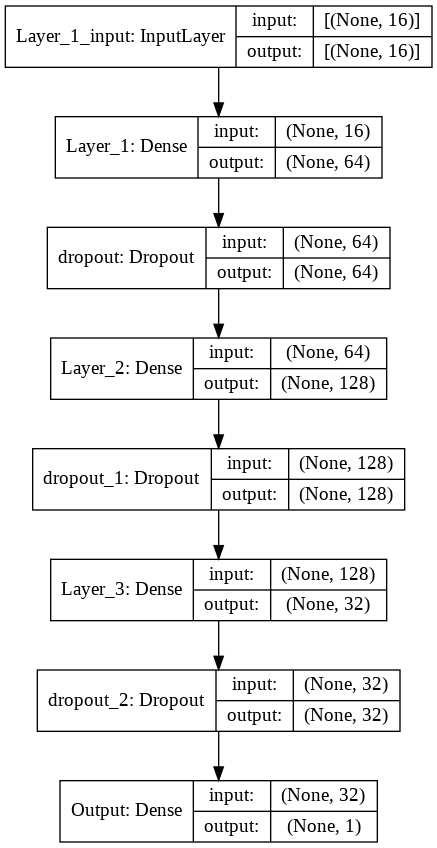

In [108]:
plot_model(model, show_shapes=True, show_layer_names=True)

## Question 5

### Compile the model

- Compile the model
- Use "adam" optimizer
- for calculating loss, use mean absolute error
- use R2 score (coefficient of determination) as the metric

In [109]:
from keras import backend as K
def r_2_score(y_true, y_pred):
    SS_resid =  K.sum(K.square( y_true-y_pred )) 
    SS_total = K.sum(K.square( y_true - K.mean(y_true) ) ) 
    return ( 1 - SS_resid/(SS_total + K.epsilon()))

In [110]:
model.compile(loss= "mean_absolute_error" , optimizer="adam", metrics=[r_2_score])

### Train your model

- epochs: 1000
- batch size: 32
- Use test data as validation data
- Also add callback, such that if validation loss doesn't decreases consecutively 10 times, stop the training and return the weights for the previous best model

In [45]:
callback=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min')

In [111]:
history=model.fit(scaledXtrain,y_train,
          validation_data=(scaledXtest,y_test),
          epochs=1000,
          batch_size=32,
          verbose=1,
         callbacks=callback)

Epoch 1/1000
186/186 [==============================] - 1s 5ms/step - loss: 651582.0802 - r_2_score: -1.1583 - val_loss: 646931.8125 - val_r_2_score: -1.0087
Epoch 2/1000
186/186 [==============================] - 1s 3ms/step - loss: 613918.8456 - r_2_score: -1.0903 - val_loss: 515520.8438 - val_r_2_score: -0.5541
Epoch 3/1000
186/186 [==============================] - 1s 3ms/step - loss: 454435.0398 - r_2_score: -0.4565 - val_loss: 328425.0625 - val_r_2_score: 0.1881
Epoch 4/1000
186/186 [==============================] - 1s 3ms/step - loss: 313389.0191 - r_2_score: 0.2021 - val_loss: 256843.8438 - val_r_2_score: 0.4922
Epoch 5/1000
186/186 [==============================] - 1s 3ms/step - loss: 281888.2829 - r_2_score: 0.4236 - val_loss: 232521.5000 - val_r_2_score: 0.5889
Epoch 6/1000
186/186 [==============================] - 1s 3ms/step - loss: 256408.5526 - r_2_score: 0.4731 - val_loss: 220143.6562 - val_r_2_score: 0.6275
Epoch 7/1000
186/186 [==============================] - 1s 

Other metrics can also be used to track the learning of the model:

To learn different metrics for classification and regression visit the following link:

Link: https://keras.io/api/metrics/#usage-with-compile-amp-fit

## Question 6

### Evaluate the model
- Evaluate the model on test data
- Visualize the model's learning

In [112]:
from keras.models import model_from_json
import numpy
import os

# Pickle model to JSON
NNDL_model_json = model.to_json()
with open("NNDL_model.json", "w") as json_file:
    json_file.write(NNDL_model_json)
    
# Pickle weights to HDF5
model.save_weights("NNDL_model.h5")
print("Saved model to disk")

# load json and create model
json_file = open('NNDL_model.json', 'r')
loaded_model_json = json_file.read()
json_file.close()
loaded_model = model_from_json(loaded_model_json)
# load weights into new model
loaded_model.load_weights("NNDL_model.h5")
print("Loaded model from disk")

Saved model to disk
Loaded model from disk


In [113]:
from keras import backend as K
def r_2_score(y_true, y_pred):
    SS_resid =  K.sum(K.square( y_true-y_pred )) 
    SS_total = K.sum(K.square( y_true - K.mean(y_true) ) ) 
    return ( 1 - SS_resid/(SS_total + K.epsilon()))

In [114]:
loaded_model.compile(loss= "mean_absolute_error" , optimizer="adam", metrics=[r_2_score])

In [115]:
score = loaded_model.evaluate(scaledXtest,y_test)
print("%s: %.2f%%" % (loaded_model.metrics_names[1], score[1]*100))

62/62 [==============================] - 0s 2ms/step - loss: 144224.3373 - r_2_score: 0.8355
r_2_score: 81.82%


- Hint: The R2 score will get affected by batch size. 

**Batch Size**: Number of samples considered in one iteration

### Check the R2 score on complete test data

In [118]:
from sklearn.metrics import r2_score
y_pred=model.predict(scaledXtest)
print(r2_score(y_test,y_pred))

0.8510149476534127


### Visualize model learning
- Visualize model learning using train and test r2 score
- Visualize model learning using train and test loss

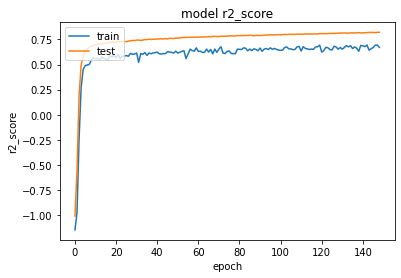

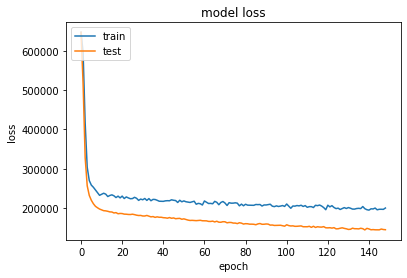

In [119]:
import matplotlib.pyplot as plt

plt.plot(history.history['r_2_score'])
plt.plot(history.history['val_r_2_score'])
plt.title('model r2_score')
plt.ylabel('r2_score')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

##  Model tuning and Hyperparameter Tuning
## Question 7 (Optional)

### Create another Deep Neural Network Model for Regression to experiment with other hyper-parameters
- Initialize a Sequential model
- Add a batch normalization layer
- Add 3 hidden layer with activation leaky-relu (Number of neurons = 64,128,32 respectively)
- Add dropout layer after each hidden layer
- Add a Dense layer with one neuron as output, use activation linear
  


In [120]:
from keras.layers import LeakyReLU

In [121]:
reg_model= Sequential()

#Batch Norm Layer -1
reg_model.add(BatchNormalization())
#input Layer -1
reg_model.add(Dense(64, input_shape = (16, ), kernel_initializer='he_normal', name='Layer_1'))
#Hidden Layer 1 - LeakyRelu
reg_model.add(LeakyReLU(alpha=0.01))
#Dropout Layer -1
reg_model.add(tf.keras.layers.Dropout(0.01))


#Batch Norm Layer -2
reg_model.add(BatchNormalization())
#input Layer -2
reg_model.add(Dense(128, kernel_initializer='he_normal', name='Layer_2'))
#Hidden Layer 2 - LeakyRelu
reg_model.add(LeakyReLU(alpha=0.01))
#Dropout Layer -2
reg_model.add(tf.keras.layers.Dropout(0.03))

#Batch Norm Layer -3
reg_model.add(BatchNormalization())
#input Layer -3
reg_model.add(Dense(32, kernel_initializer='he_normal', name='Layer_3'))
#Hidden Layer 3 - LeakyRelu
reg_model.add(LeakyReLU(alpha=0.01))
#Dropout Layer -2
reg_model.add(tf.keras.layers.Dropout(0.05))

reg_model.add(BatchNormalization())

#Output layer - 1 neuron 
reg_model.add(tf.keras.layers.Dense(1, activation='linear', name='Output'))

### Compile the model

- Compile the model
- Use "adam" optimizer 
- for calculating loss, use mean absolute error
- use R2 score (coefficient of determination) as the metric

In [122]:
from keras import backend as K
def r_2_score(y_true, y_pred):
    SS_resid =  K.sum(K.square( y_true-y_pred )) 
    SS_total = K.sum(K.square( y_true - K.mean(y_true) ) ) 
    return ( 1 - SS_resid/(SS_total + K.epsilon()))

In [123]:
reg_model.compile(loss= "mean_absolute_error" , optimizer="adam", metrics=[r_2_score])

### Train your model

- epochs: 1000
- batch size: 16
- Use test data as validation data
- Also add callback, such that if validation loss doesn't decreases consecutively 10 times, stop the training and return the weights for the previous best model
- Add checkpoints to save the model after every epoch


In [125]:
from tensorflow.keras.callbacks import ModelCheckpoint
check_point = ModelCheckpoint('./checkpoint1', monitor='val_loss',save_best_only=True,save_freq='epoch')

In [126]:
callback=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min')

In [127]:
reg_history=reg_model.fit(scaledXtrain,y_train,
          validation_data=(scaledXtest,y_test),
          epochs=1000,
          batch_size=16,
          verbose=1,
         callbacks=[callback,check_point])

Epoch 1/1000
371/371 [==============================] - 3s 5ms/step - loss: 656058.9242 - r_2_score: -1.7774 - val_loss: 654298.0000 - val_r_2_score: -1.8264
INFO:tensorflow:Assets written to: ./checkpoint1/assets
Epoch 2/1000
371/371 [==============================] - 2s 4ms/step - loss: 655437.6208 - r_2_score: -1.8013 - val_loss: 654263.7500 - val_r_2_score: -1.8261
INFO:tensorflow:Assets written to: ./checkpoint1/assets
Epoch 3/1000
371/371 [==============================] - 2s 4ms/step - loss: 637651.7554 - r_2_score: -1.8536 - val_loss: 654208.5625 - val_r_2_score: -1.8257
INFO:tensorflow:Assets written to: ./checkpoint1/assets
Epoch 4/1000
371/371 [==============================] - 2s 5ms/step - loss: 652724.0444 - r_2_score: -1.7356 - val_loss: 654138.3750 - val_r_2_score: -1.8252
INFO:tensorflow:Assets written to: ./checkpoint1/assets
Epoch 5/1000
371/371 [==============================] - 2s 4ms/step - loss: 639667.4211 - r_2_score: -1.9290 - val_loss: 654051.1875 - val_r_2_s

In [128]:
#Evaluate the model
score = reg_model.evaluate(scaledXtest,y_test)
print("%s: %.2f%%" % (reg_model.metrics_names[1], score[1]*100))

62/62 [==============================] - 0s 2ms/step - loss: 264720.5938 - r_2_score: 0.2907
r_2_score: 29.07%


### Check the R2 score on complete test data

In [129]:
from sklearn.metrics import r2_score
y_pred=reg_model.predict(scaledXtest)
print(r2_score(y_test,y_pred))

0.22540180633044216


### Visualize model learning
- Visualize model learning using train and test r2 score
- Visualize model learning using train and test loss

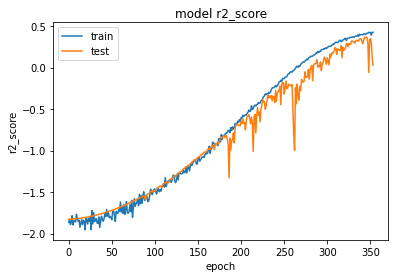

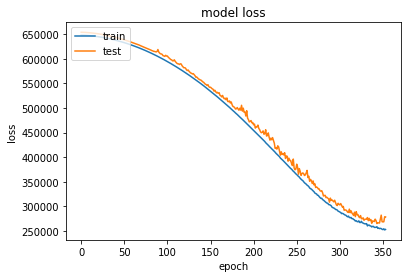

In [130]:
plt.plot(reg_history.history['r_2_score'])
plt.plot(reg_history.history['val_r_2_score'])
plt.title('model r2_score')
plt.ylabel('r2_score')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(reg_history.history['loss'])
plt.plot(reg_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Create another Deep Neural Network Model for Regression to experiment with other hyper-parameters
- Initialize a Sequential model
- Add a batch normalization layer
- Intialize weights using HeUniform with seed = 7
- Add 4 hidden layer with activation relu (Number of neurons = 256,128,64,32 in each layer respectively)
- Add dropout layer after each hidden layer
- Add a Dense layer with one neuron as output, use activation linear
  


In [73]:
reg_model2= Sequential()

#Batch Norm Layer -1
reg_model2.add(BatchNormalization())
#input Layer -1
initializer = tf.keras.initializers.HeUniform(seed=7)
reg_model2.add(Dense(256, input_shape = (16, ), kernel_initializer=initializer, activation='relu', name='Layer_1'))

#Dropout Layer -1
reg_model2.add(tf.keras.layers.Dropout(0.01))


#Batch Norm Layer -2
reg_model2.add(BatchNormalization())
#input Layer -2
reg_model2.add(Dense(128, kernel_initializer=initializer, activation='relu', name='Layer_2'))

#Dropout Layer -2
reg_model2.add(tf.keras.layers.Dropout(0.03))


#Batch Norm Layer -3
reg_model2.add(BatchNormalization())
#input Layer -3
reg_model2.add(Dense(64, kernel_initializer=initializer, activation='relu', name='Layer_3'))

#Dropout Layer -3
reg_model2.add(tf.keras.layers.Dropout(0.05))

#Batch Norm Layer -4
reg_model2.add(BatchNormalization())
#input Layer -4
reg_model2.add(Dense(32, kernel_initializer=initializer, activation='relu', name='Layer_4'))

#Dropout Layer -4
reg_model2.add(tf.keras.layers.Dropout(0.05))

reg_model2.add(BatchNormalization())

#Output layer - 1 neuron 
reg_model2.add(tf.keras.layers.Dense(1, activation='linear', name='Output'))

### Compile the model

- Compile the model
- Use "adam" optimizer with learning rate = 0.002
- for calculating loss, use mean squared error
- use R2 score (coefficient of determination) as the metric

In [131]:
adam = optimizers.Adam(lr = 0.002)
reg_model2.compile(loss= "mean_squared_error" , optimizer=adam, metrics=[r_2_score])

### Train your model

- epochs: 1000
- batch size: 64
- Use test data as validation data
- Also add callback, such that if validation loss doesn't decreases consecutively 10 times, stop the training and return the weights for the previous best model



In [132]:
from tensorflow.keras.callbacks import ModelCheckpoint
check_point = ModelCheckpoint('./checkpoint', monitor='val_loss',save_best_only=True,save_freq='epoch')
callback=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min')
reg_history2=reg_model2.fit(scaledXtrain,y_train,
          validation_data=(scaledXtest,y_test),
          epochs=1000,
          batch_size=64,
          verbose=1,
         callbacks=[callback,check_point])

Epoch 1/1000
93/93 [==============================] - 2s 8ms/step - loss: 753788372686.9788 - r_2_score: -0.3382 - val_loss: 849037230080.0000 - val_r_2_score: -0.3062
INFO:tensorflow:Assets written to: ./checkpoint/assets
Epoch 2/1000
93/93 [==============================] - 1s 6ms/step - loss: 797864128076.2554 - r_2_score: -0.3413 - val_loss: 839819395072.0000 - val_r_2_score: -0.2912
INFO:tensorflow:Assets written to: ./checkpoint/assets
Epoch 3/1000
93/93 [==============================] - 1s 6ms/step - loss: 723543489688.5106 - r_2_score: -0.3412 - val_loss: 834526642176.0000 - val_r_2_score: -0.2836
INFO:tensorflow:Assets written to: ./checkpoint/assets
Epoch 4/1000
93/93 [==============================] - 1s 6ms/step - loss: 879654204699.2340 - r_2_score: -0.2822 - val_loss: 838907592704.0000 - val_r_2_score: -0.2871
Epoch 5/1000
93/93 [==============================] - 1s 6ms/step - loss: 768060516918.4681 - r_2_score: -0.3267 - val_loss: 825474285568.0000 - val_r_2_score: -0.

### Check the R2 score on complete test data

In [133]:
#Evaluate the model
score = reg_model.evaluate(scaledXtest,y_test)
print("%s: %.2f%%" % (reg_model.metrics_names[1], score[1]*100))

62/62 [==============================] - 0s 2ms/step - loss: 264720.5938 - r_2_score: 0.2907
r_2_score: 29.07%


In [134]:
y_pred=reg_model2.predict(scaledXtest)
print(r2_score(y_test,y_pred))

0.35531053690011016


### Visualize model learning
- Visualize model learning using train and test r2 score
- Visualize model learning using train and test loss

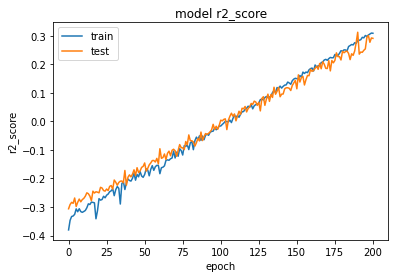

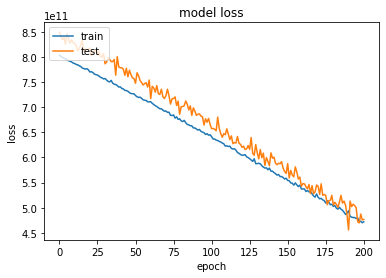

In [135]:
plt.plot(reg_history2.history['r_2_score'])
plt.plot(reg_history2.history['val_r_2_score'])
plt.title('model r2_score')
plt.ylabel('r2_score')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(reg_history2.history['loss'])
plt.plot(reg_history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()